# FRB Isotropy Analysis Notebook
Este notebook configura o ambiente para `src/`, importa o pacote `frb_isotropy`, e mostra como criar uma configuração de análise.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print('cwd =', ROOT)
print('src =', SRC)
print('python =', sys.executable)
print('sys.path[0:5] =', sys.path[:5])

try:
    import frb_isotropy
    print('Imported frb_isotropy successfully')
except Exception as exc:
    import traceback
    traceback.print_exc()

from pprint import pprint
print('frb_isotropy public attributes:')
pprint([name for name in dir(frb_isotropy) if not name.startswith('_')])

cwd = /home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy
src = /home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/src
python = /home/brunowesley/projetos/venv/bin/python
sys.path[0:5] = ['/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/home/brunowesley/projetos/venv/lib/python3.12/site-packages']
Imported frb_isotropy successfully
frb_isotropy public attributes:
['AnalysisConfig',
 'OutputPaths',
 'RuntimeContext',
 'analysis',
 'catalog',
 'core',
 'create_runtime_context',
 'main',
 'pipeline',
 'reporting',
 'selection',
 'simulations',
 'statistics',
 'visualization']


In [2]:
from frb_isotropy.core.config import (
    AnalysisConfig,
    OutputPaths,
    create_runtime_context,
)

from frb_isotropy import main

print('AnalysisConfig is available:', AnalysisConfig)
print('OutputPaths is available:', OutputPaths)
print('create_runtime_context is available:', create_runtime_context)
print('main is available:', main)

AnalysisConfig is available: <class 'frb_isotropy.core.config.AnalysisConfig'>
OutputPaths is available: <class 'frb_isotropy.core.config.OutputPaths'>
create_runtime_context is available: <function create_runtime_context at 0x7d3dcdbe31a0>
main is available: <function main at 0x7d3d26f9f1a0>


In [3]:
from pathlib import Path

from frb_isotropy.core.config import AnalysisConfig, create_runtime_context


project_root = Path.cwd()
outputs_root = project_root / 'outputs'
possible_catalogs = [
    project_root / 'data' / 'SkyPosition.csv',
]
catalog_path = next((path for path in possible_catalogs if path.exists()), None)


print('Checked possible catalog locations:')
for path in possible_catalogs:
    print(' -', path, 'exists=', path.exists())

if catalog_path is None:
    raise FileNotFoundError('Nenhum catálogo encontrado em data/ ou ../FRB_catalogs/')

config = AnalysisConfig(
    name='SFweightedIsotropy',
    project_root=project_root,
    outputs_root=outputs_root,
    catalog_path=catalog_path,
    use_gal_mask=True,
    use_sel_func=True,
    n_jobs=100,
    gal_cut=20.0,
    min_sep=0.0,
    max_sep=180.0,
    bin_size=10,
    coarse_bins=(0.0, 20.0, 40.0, 60.0, 80.0, 100.0, 120.0, 140.0, 160.0, 180.0),
    nside_sf=32,
    smooth_sigma=3.0,
    perturbation_scale=1.0,
    n_rand_factor=20,
    n_ensemble=20,
    n_mocks_per_ensemble=50,

    # ------------------------------------------------------
    # RNG seeds
    # ------------------------------------------------------

    random_seed=12345,
    mock_seed_base=100000,
    random_catalog_seed_base=200000,
    sf_perturbation_seed_base=300000,
    jackknife_seed_base=400000,
    bootstrap_seed_base=500000,

    # ------------------------------------------------------
    # Numerical stability
    # ------------------------------------------------------

    selection_function_floor=1e-12,
    numerical_eigenvalue_floor=1e-15,
    stable_eigenvalue_floor=1e-12,
    numerical_zero_tolerance=1e-30,

    # ------------------------------------------------------
    # Covariance regularization
    # ------------------------------------------------------

    svd_eigenvalue_cut=1e-2,

    # ------------------------------------------------------
    # Jackknife
    # ------------------------------------------------------

    nside_jackknife=4,
    min_jackknife_regions=20,

    # ------------------------------------------------------
    # Bootstrap
    # ------------------------------------------------------

    n_bootstrap=500,

    # ------------------------------------------------------
    # Overlap analysis
    # ------------------------------------------------------

    overlap_radius_deg=5.0,
    overlap_nside=32,

    # ------------------------------------------------------
    # Optional pipeline products
    # ------------------------------------------------------

    run_top_survey_maps=True,
)

print('Using catalog_path =', catalog_path)
print(config)
context = create_runtime_context(config)
print('Runtime context created successfully')
print(context)

Checked possible catalog locations:
 - /home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/data/SkyPosition.csv exists= True
Using catalog_path = /home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/data/SkyPosition.csv
AnalysisConfig(name='SFweightedIsotropy', project_root=PosixPath('/home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy'), outputs_root=PosixPath('/home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/outputs'), catalog_path=PosixPath('/home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/data/SkyPosition.csv'), use_gal_mask=True, use_sel_func=True, n_jobs=100, gal_cut=20.0, min_sep=0.0, max_sep=180.0, bin_size=10, coarse_bins=(0.0, 20.0, 40.0, 60.0, 80.0, 100.0, 120.0, 140.0, 160.0, 180.0), nside_sf=32, smooth_sigma=3.0, perturbation_scale=1.0, n_rand_factor=20, n_ensemble=20, n_mocks_per_ensemble=50, random_seed=12345, mock_seed_base=100000, random_catalog_seed_base=200000, sf_perturbation_seed_base=300000, jac


FRB ISOTROPY PIPELINE
RUN TAG                  : SFweightedIsotropy_mask_sf_gal20_bin10_nside32_smooth3
PROJECT ROOT             : /home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy
CATALOG PATH             : /home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/data/SkyPosition.csv
OUTPUT ROOT              : /home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/outputs
USE GAL MASK             : True
USE SEL FUNC             : True
N JOBS                   : 100
GAL CUT                  : 20.0
MIN SEP                  : 0.0
MAX SEP                  : 180.0
BIN SIZE                 : 10
N BINS                   : 18
COARSE BINS              : (0.0, 20.0, 40.0, 60.0, 80.0, 100.0, 120.0, 140.0, 160.0, 180.0)
NSIDE SF                 : 32
SMOOTH SIGMA             : 3.0
PERTURBATION SCALE       : 1.0
N RAND FACTOR            : 20
N ENSEMBLE               : 20
N MOCKS PER ENSEMBLE     : 50
TOTAL H0 MOCKS           : 1000
SVD EIGENVALUE CUT       : 0.01
N

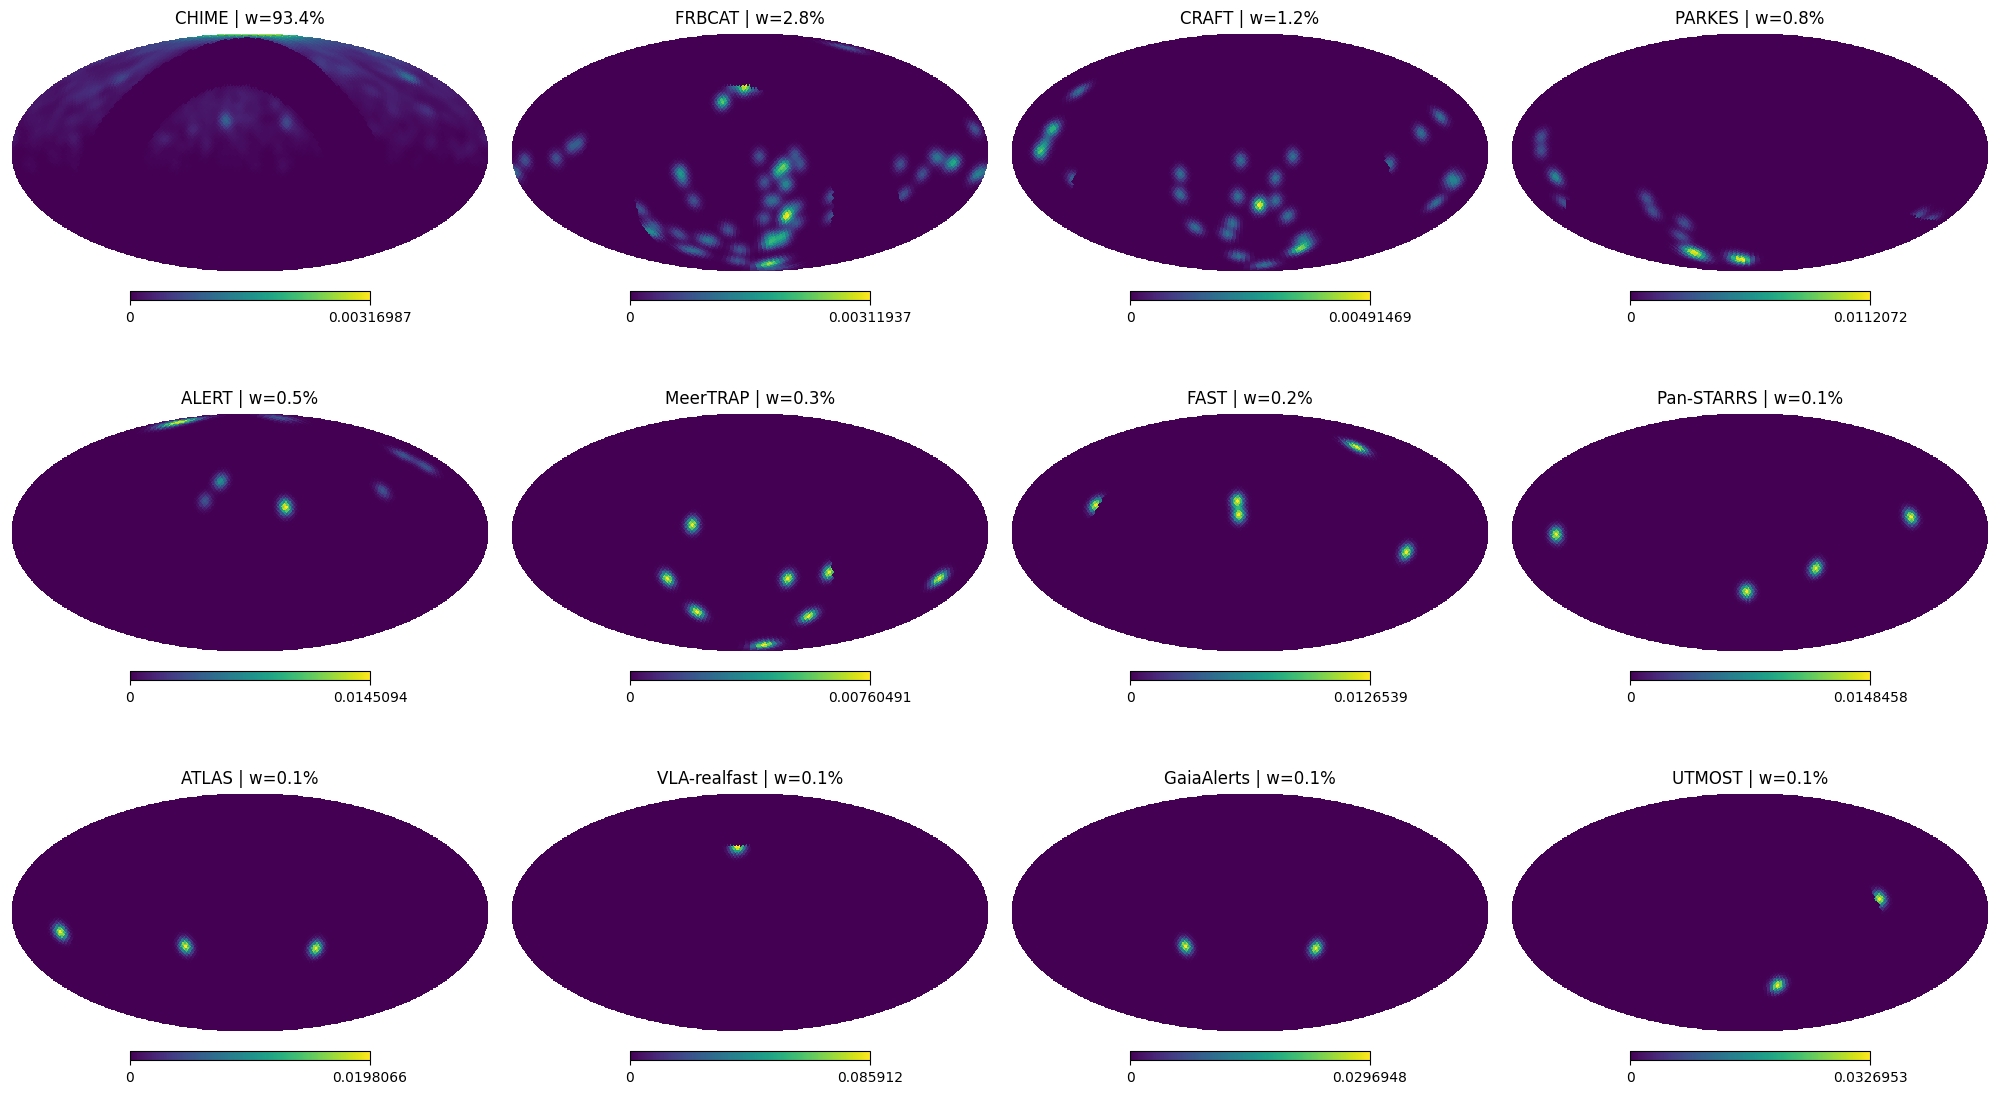

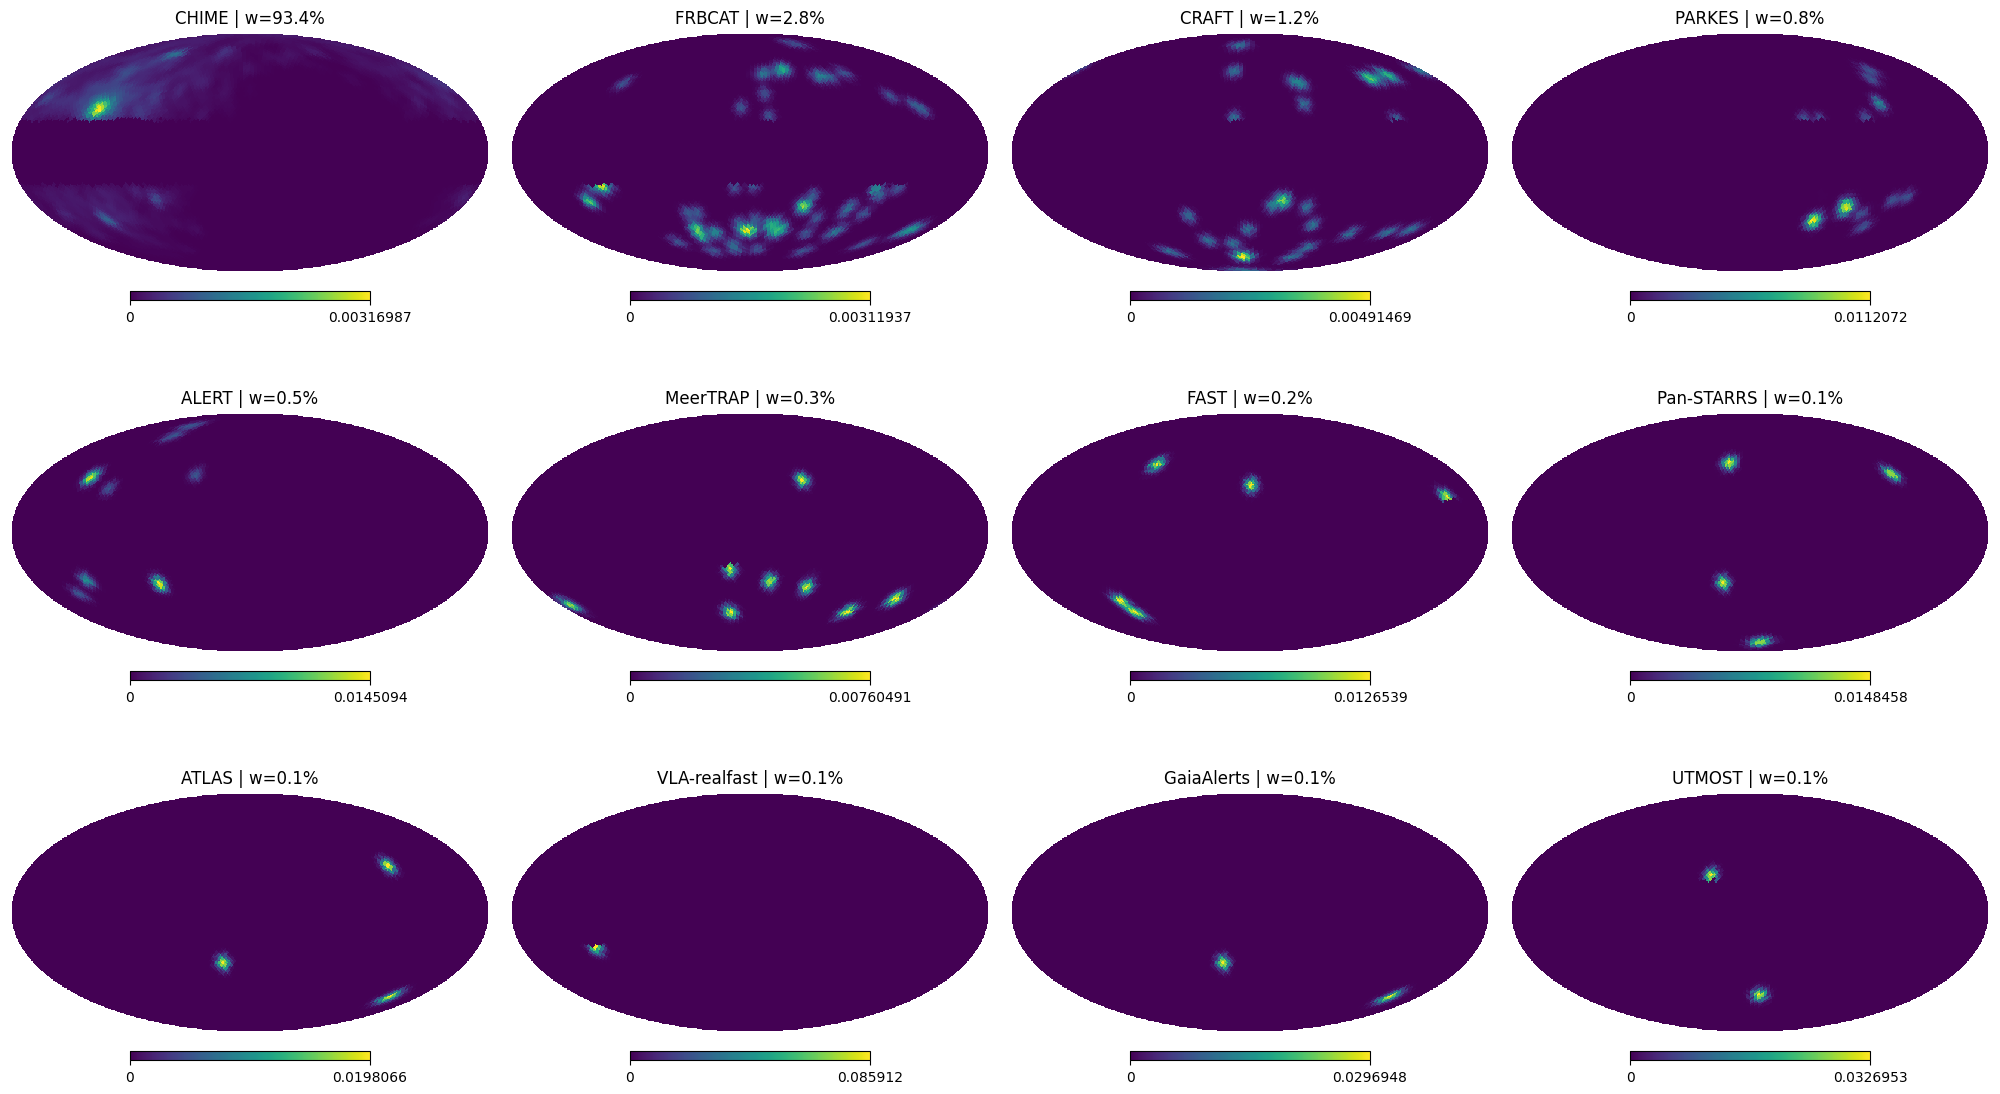


Selection-function maps saved:
  /home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/outputs/SFweightedIsotropy_mask_sf_gal20_bin10_nside32_smooth3/figures/sf_validation_equatorial.png
  /home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/outputs/SFweightedIsotropy_mask_sf_gal20_bin10_nside32_smooth3/figures/sf_validation_galactic.png


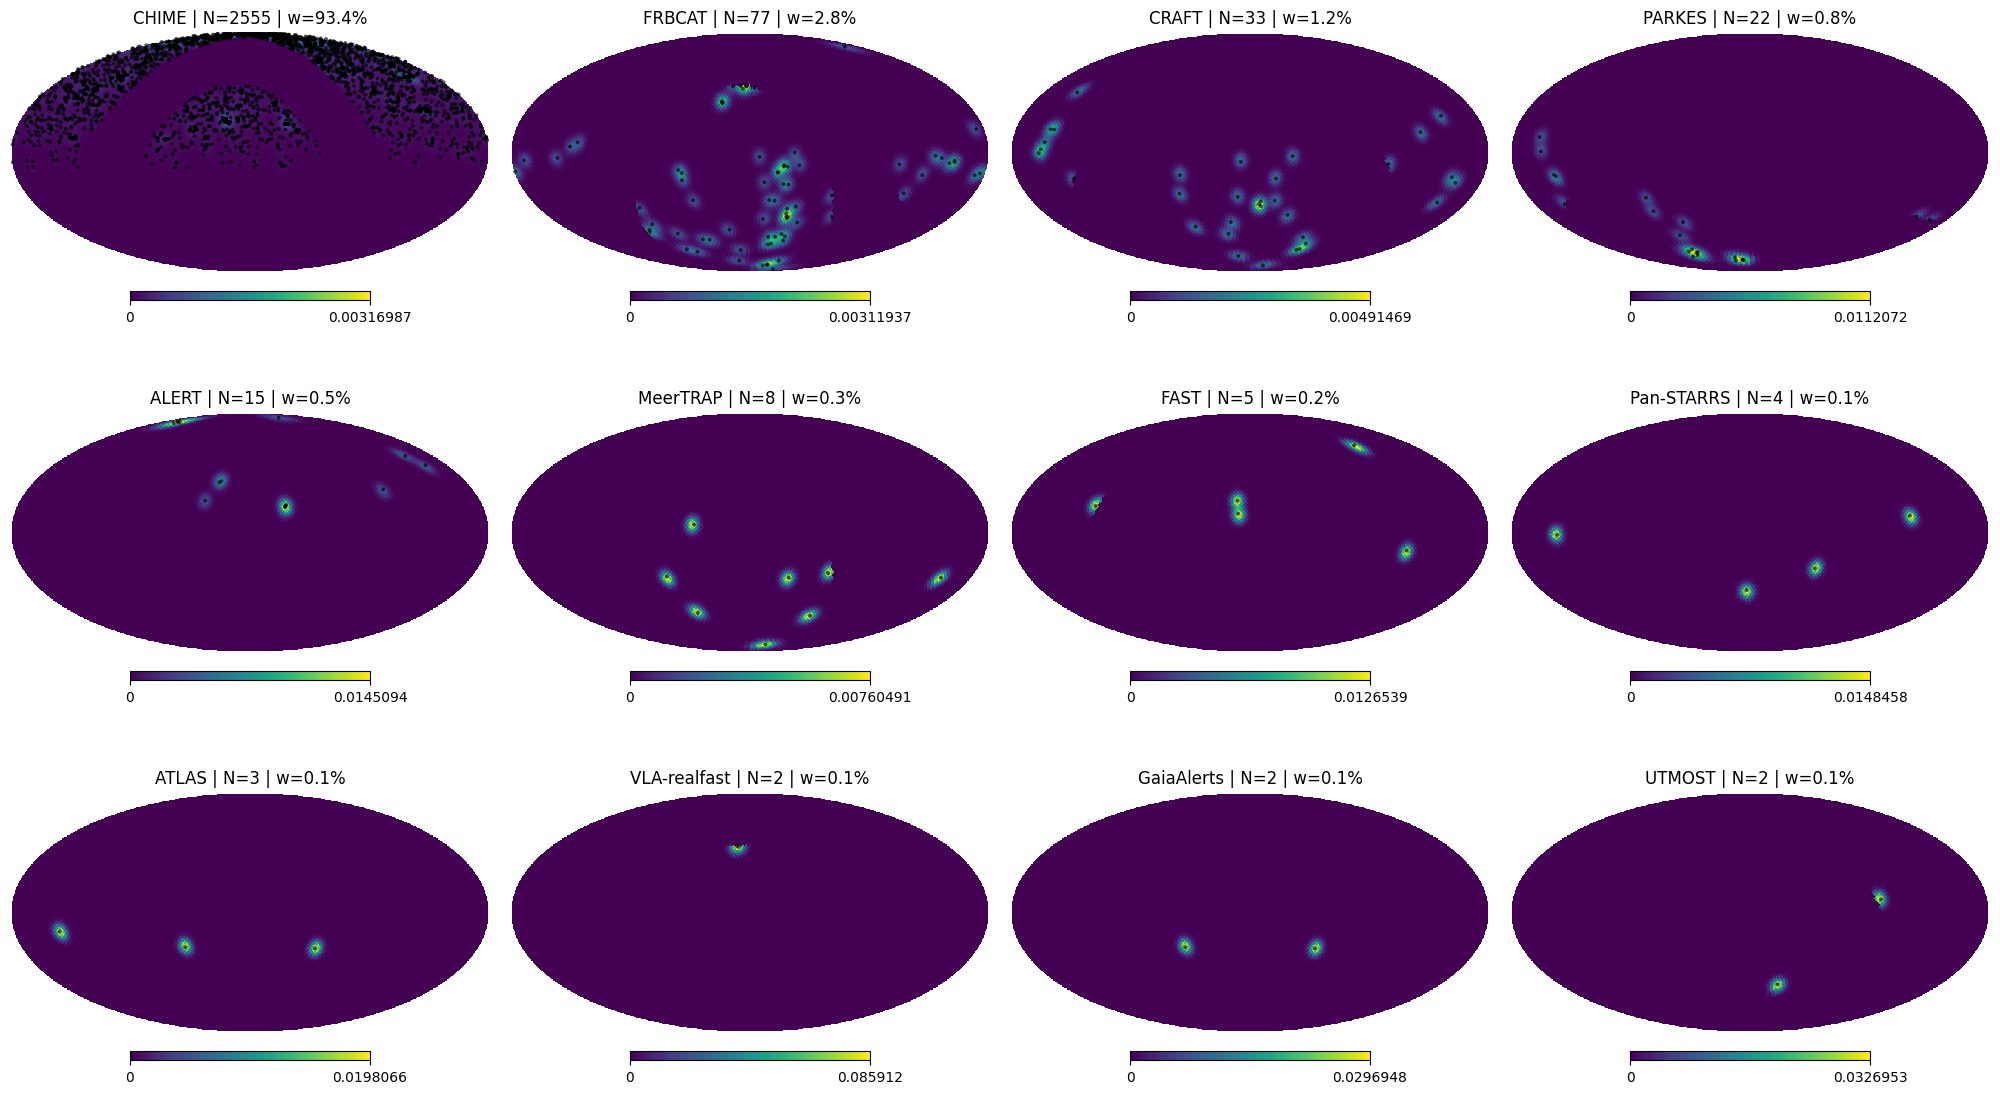

Saved survey maps: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/outputs/SFweightedIsotropy_mask_sf_gal20_bin10_nside32_smooth3/figures/survey_maps_equatorial.png


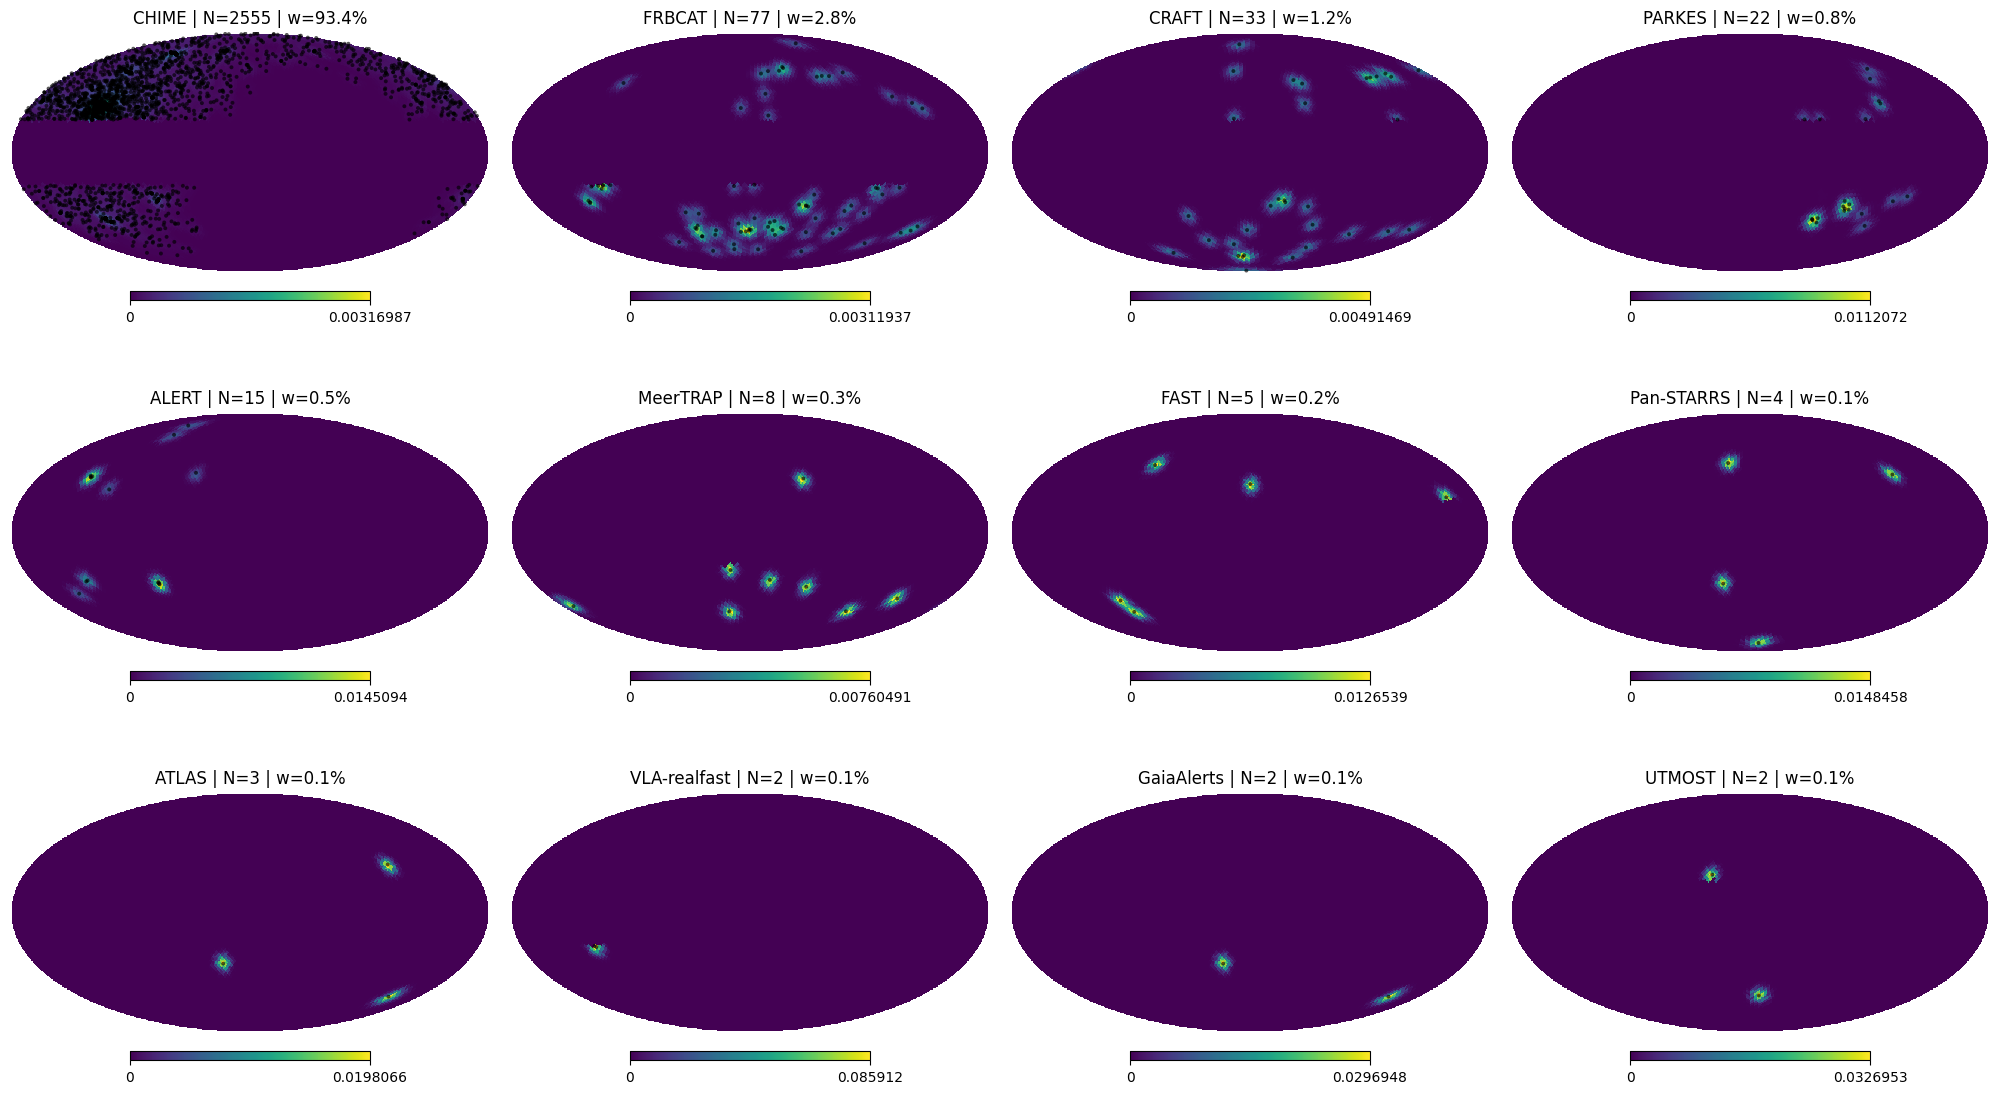

Saved survey maps: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/outputs/SFweightedIsotropy_mask_sf_gal20_bin10_nside32_smooth3/figures/survey_maps_galactic.png

INTERSURVEY DIAGNOSTICS

INTERSURVEY CORRELATION ANALYSIS

--- Spatial correlation summary ---
Mean survey correlation: 0.0097
Max survey correlation: 0.8165
Mean overlap fraction: 5.84%
Max overlap fraction: 100.00%

High overlap/correlation pairs may indicate non-independent observational footprints.

OBSERVED RANDOM CATALOG
Observed random catalog size = 54640

OBSERVED ANGULAR STATISTICS

JACKKNIFE UNCERTAINTIES

JACKKNIFE UNCERTAINTY ESTIMATION
RUN_TAG = SFweightedIsotropy_mask_sf_gal20_bin10_nside32_smooth3

--- Jackknife region assignment ---
NSIDE_JACKKNIFE = 4
Populated regions = 131

--- Jackknife region statistics ---
Objects per region:
min    = 1
median = 9.0
max    = 179


Jackknife regions:   0%|          | 0/131 [00:00<?, ?it/s]

  0%|          | 0/131 [00:00<?, ?it/s]


--- Jackknife summary ---
Leave-one-region samples = 131
Objects kept per sample:
min = 2553
max = 2731
Median sigma[w(theta)] = 1.3861e-02
Median sigma[|<w>|] = 1.9223e-02

--- Covariance correlation diagnostics ---
Mean off-diagonal corr: -0.0483
Median off-diagonal corr: -0.0496
95th percentile corr: 0.2514
Max off-diagonal corr: 0.4627


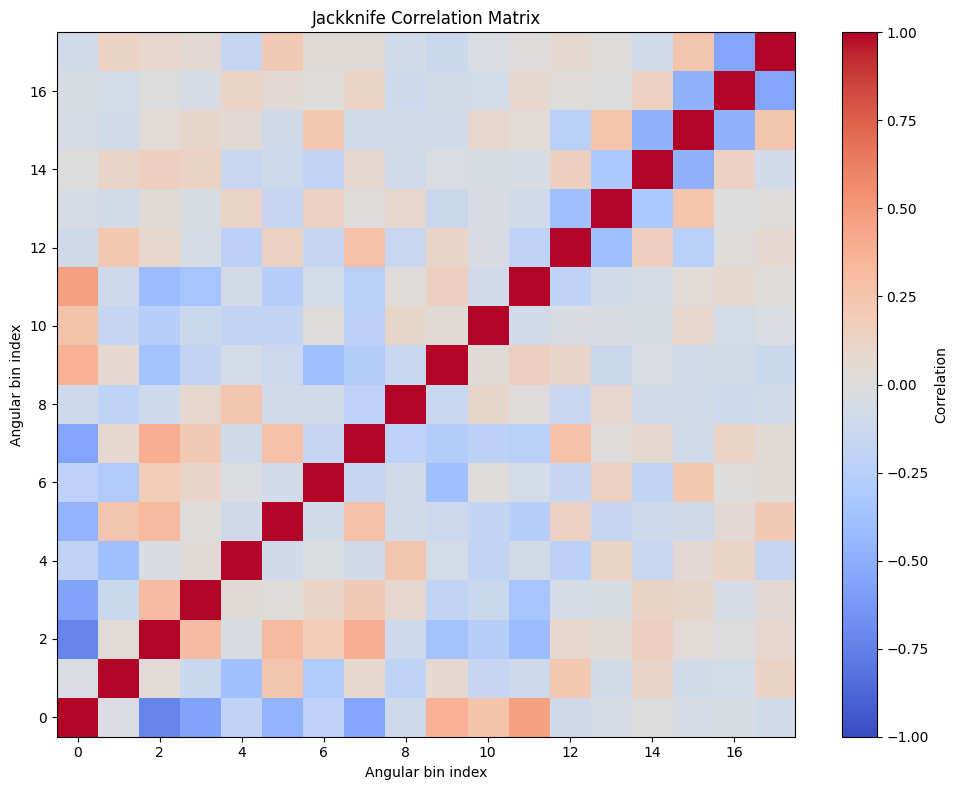


Saved correlation matrix:
  /home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/outputs/SFweightedIsotropy_mask_sf_gal20_bin10_nside32_smooth3/figures/jackknife_correlation_matrix

BOOTSTRAP UNCERTAINTIES

BOOTSTRAP UNCERTAINTY ESTIMATION
RUN_TAG = SFweightedIsotropy_mask_sf_gal20_bin10_nside32_smooth3

Bootstrap realizations = 500

Generating fixed random catalog...
Random catalog size = 54640


Bootstrap realizations:   0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]


--- Bootstrap summary ---
Median sigma[w(theta)] = 3.5965e-03
Median sigma[|<w>|] = 4.1819e-03
Max sigma[w(theta)] = 1.3029e-02
Max sigma[|<w>|] = 9.3855e-03

--- Covariance correlation diagnostics ---
Mean off-diagonal corr: -0.0515
Median off-diagonal corr: -0.0315
95th percentile corr: 0.0924
Max off-diagonal corr: 0.1508


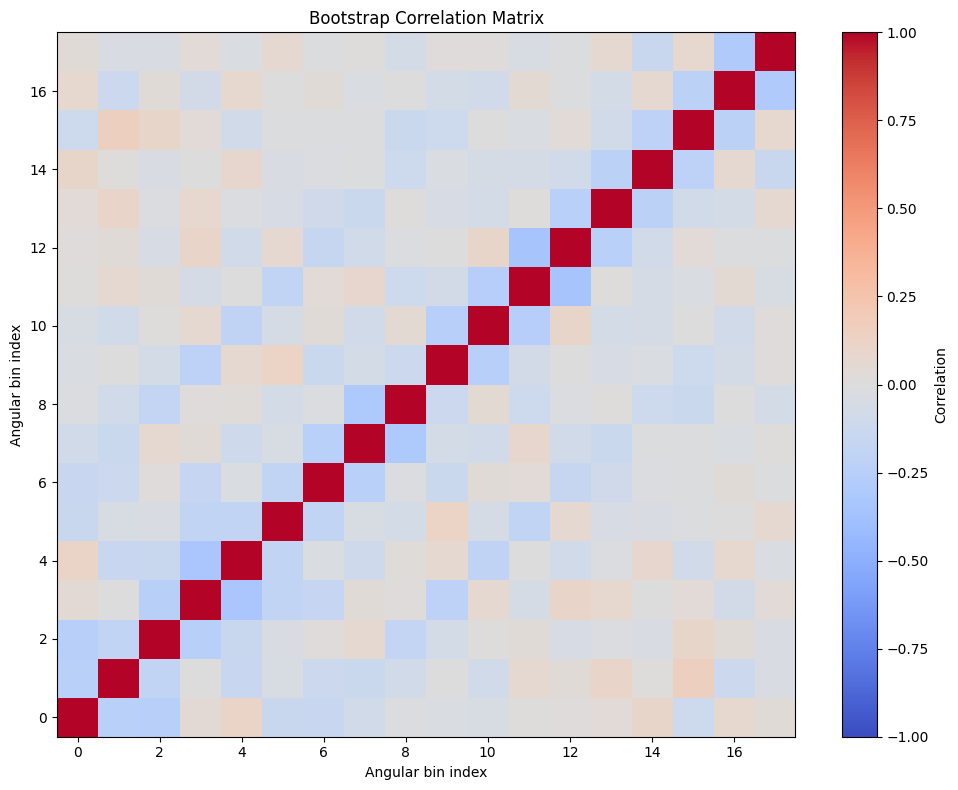


Saved correlation matrix:
  /home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/outputs/SFweightedIsotropy_mask_sf_gal20_bin10_nside32_smooth3/figures/bootstrap_correlation_matrix

H0 ENSEMBLE

--- Generating H0 ensemble mocks (with selection functions) ---
Total H0 mocks: 1000


H0 ensemble mocks:   0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]


Generated mocks:
  w(theta): (1000, 18)
  |<w>| tomography: (1000, 9)

STATISTICAL INFERENCE

GLOBAL ISOTROPY INFERENCE
RUN_TAG = SFweightedIsotropy_mask_sf_gal20_bin10_nside32_smooth3
USE_GAL_MASK = True
USE_SEL_FUNC = True

Max |H0 mean| = 5.2943e-04

--- Covariance correlation diagnostics ---
Mean off-diagonal corr: -0.0524
Median off-diagonal corr: -0.0464
95th percentile corr: 0.0161
Max off-diagonal corr: 0.0594


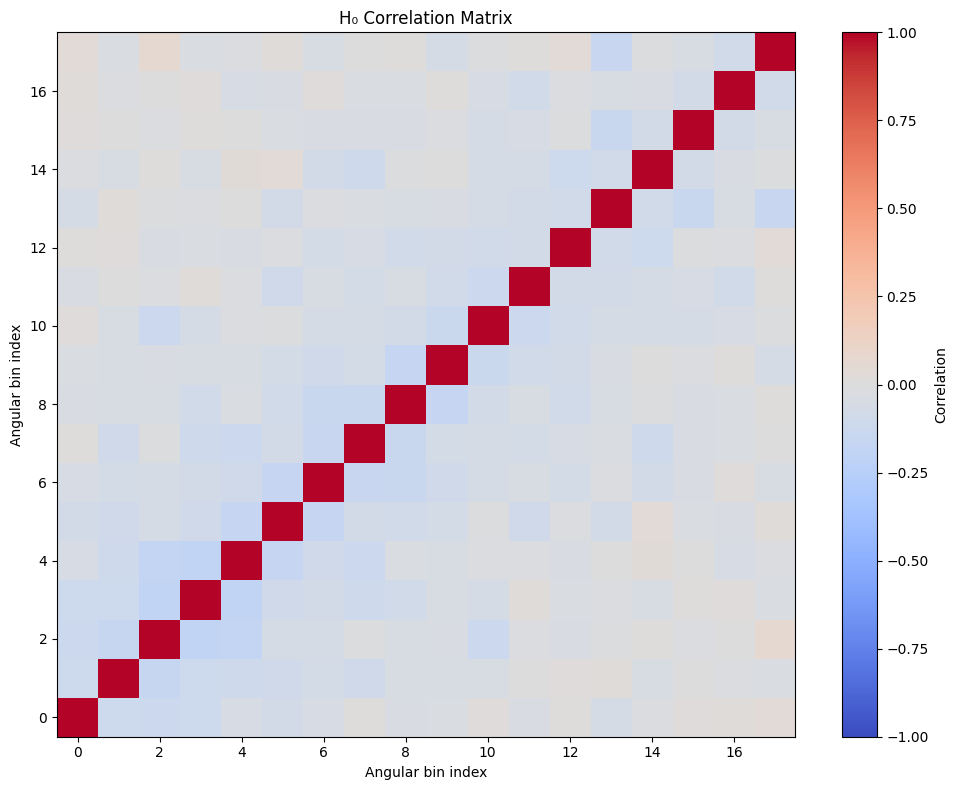


Saved correlation matrix:
  /home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/outputs/SFweightedIsotropy_mask_sf_gal20_bin10_nside32_smooth3/figures/h0_correlation_matrix.png

MOCK SIMILARITY DIAGNOSTICS
Mocks analyzed: 100
Mean off-diagonal corr: -0.0097
Median off-diagonal corr: -0.0114
95th percentile corr: 0.4037
99th percentile corr: 0.5496
Max off-diagonal corr: 0.7604

Interpretation:
  ⚠ Strong mock correlations detected.
  Covariance estimation may be biased.


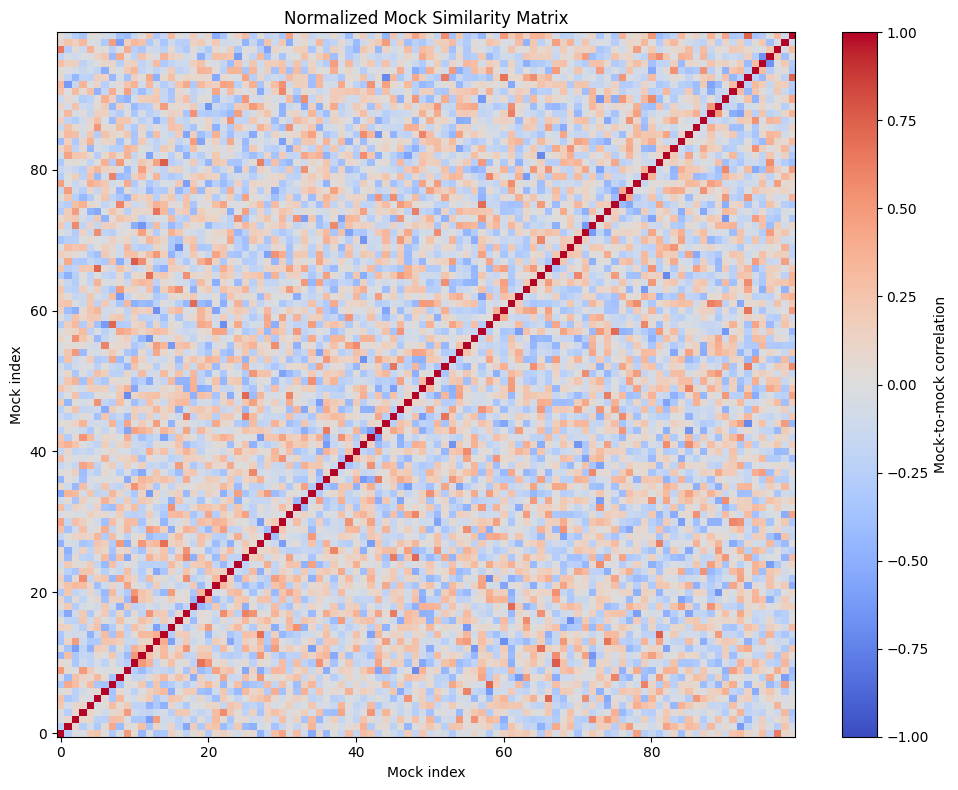


Saved mock similarity matrix:
  /home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/outputs/SFweightedIsotropy_mask_sf_gal20_bin10_nside32_smooth3/figures/h0_mock_similarity.png


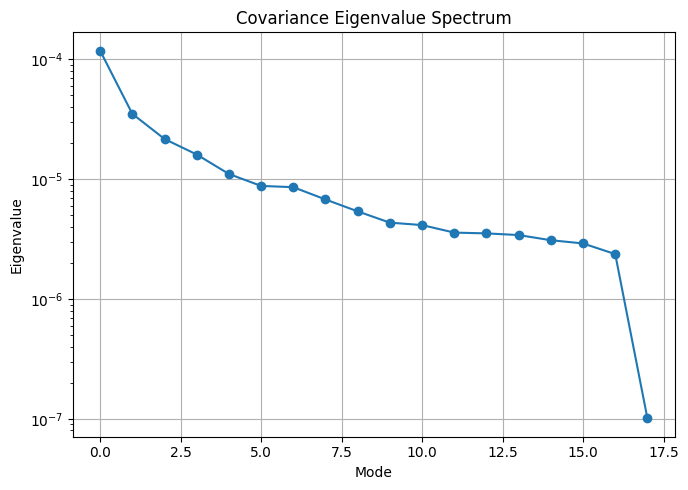


--- SVD covariance regularization ---
Modes kept: 17/18
Eigenvalue threshold: 1.00e-02
Explained variance kept: 99.96%
SVD condition number: 4.98e+01

--- Full covariance diagnostic (FRB isotropy (SFweightedIsotropy_mask_sf_gal20_bin10_nside32_smooth3)) ---
Chi2 = 22.316
Chi2/dof = 1.313
p-value (Chi2 analytic) = 1.7287e-01
p-value (Chi2 empirical) = 1.7083e-01
Sigma-equivalent (from empirical p) = 0.95

--- Primary isotropy statistic (SVD-regularized) ---
Eigenvalue cut = 1.0e-02
SVD modes kept = 17/18
Chi2 SVD = 22.240
Chi2 SVD/dof = 1.308
p-value SVD (Chi2 analytic) = 1.7567e-01
p-value SVD (empirical) = 1.7183e-01
Sigma-equivalent SVD (from empirical p) = 0.95

--- Covariance diagnostics ---
Mocks = 1000
Bins = 18
Covariance rank = 18/18
Covariance condition number = 1.1693e+03
SVD retained condition number = 4.9804e+01
Effective modes = 4.10
Hartlap factor = 0.981

--- Absolute-sum statistic ---
Observed total = 3.7749e-02
Empirical p-value = 7.1429e-01
RMS normalized deviation =

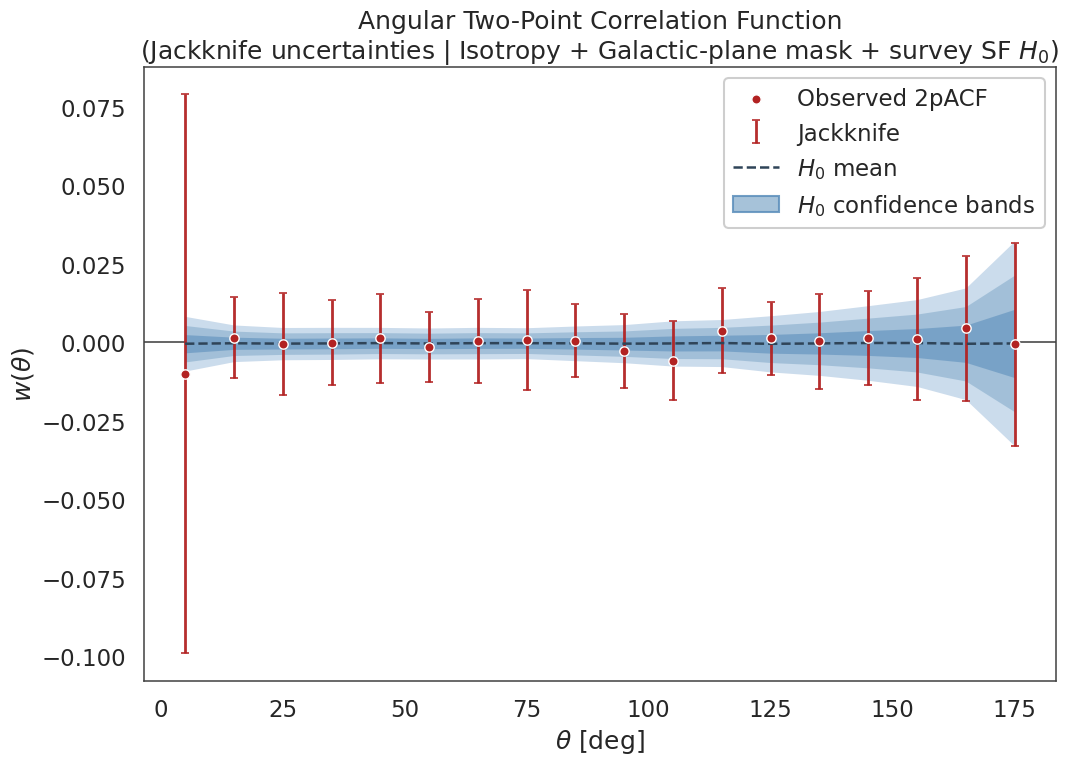

Saved: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/outputs/SFweightedIsotropy_mask_sf_gal20_bin10_nside32_smooth3/figures/2pacf_jackknife.png


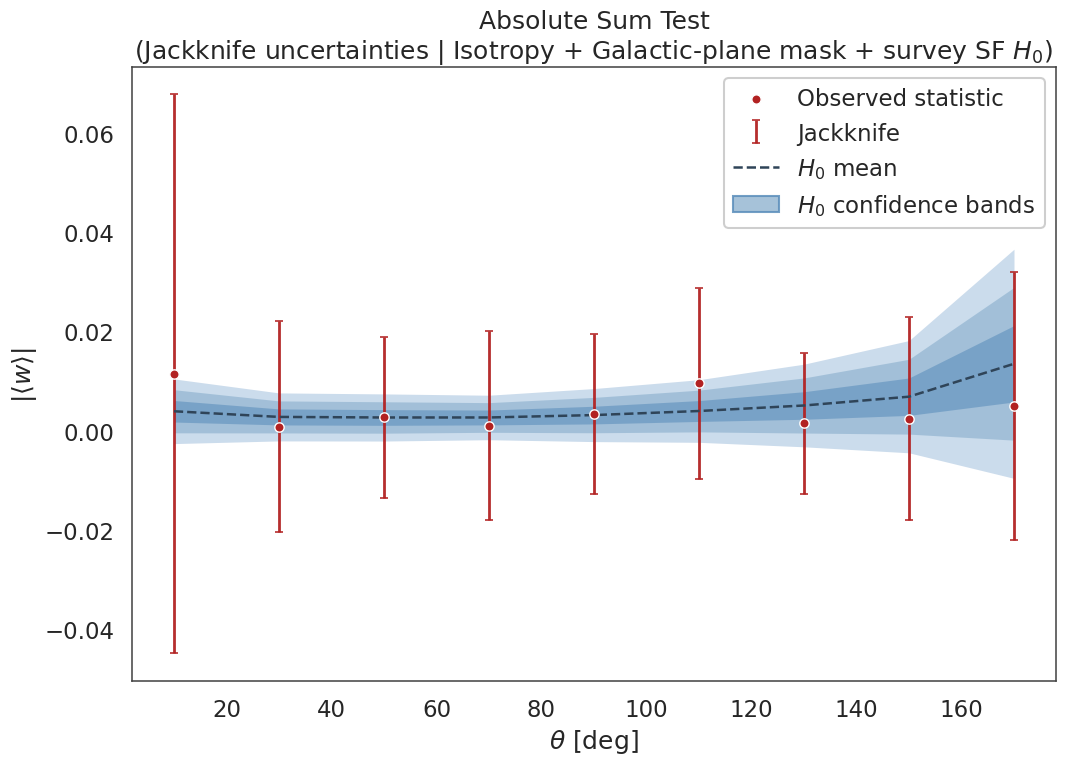

Saved: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/outputs/SFweightedIsotropy_mask_sf_gal20_bin10_nside32_smooth3/figures/absolute_anisotropy_jackknife.png


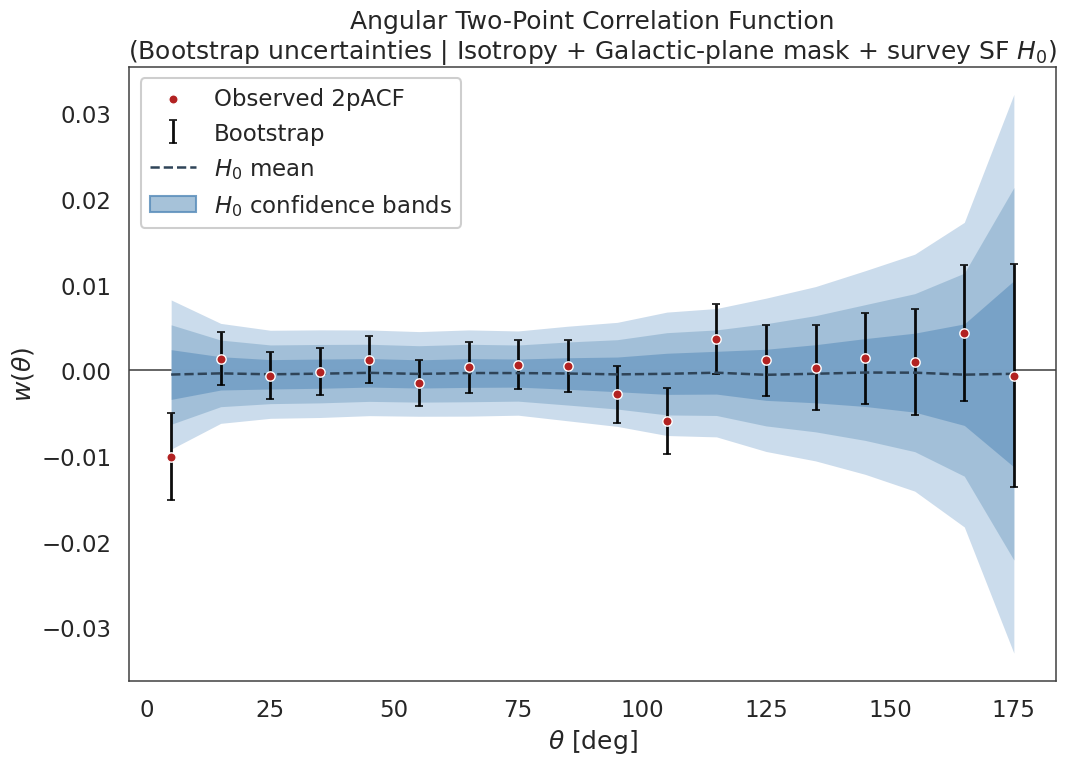

Saved: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/outputs/SFweightedIsotropy_mask_sf_gal20_bin10_nside32_smooth3/figures/2pacf_bootstrap.png


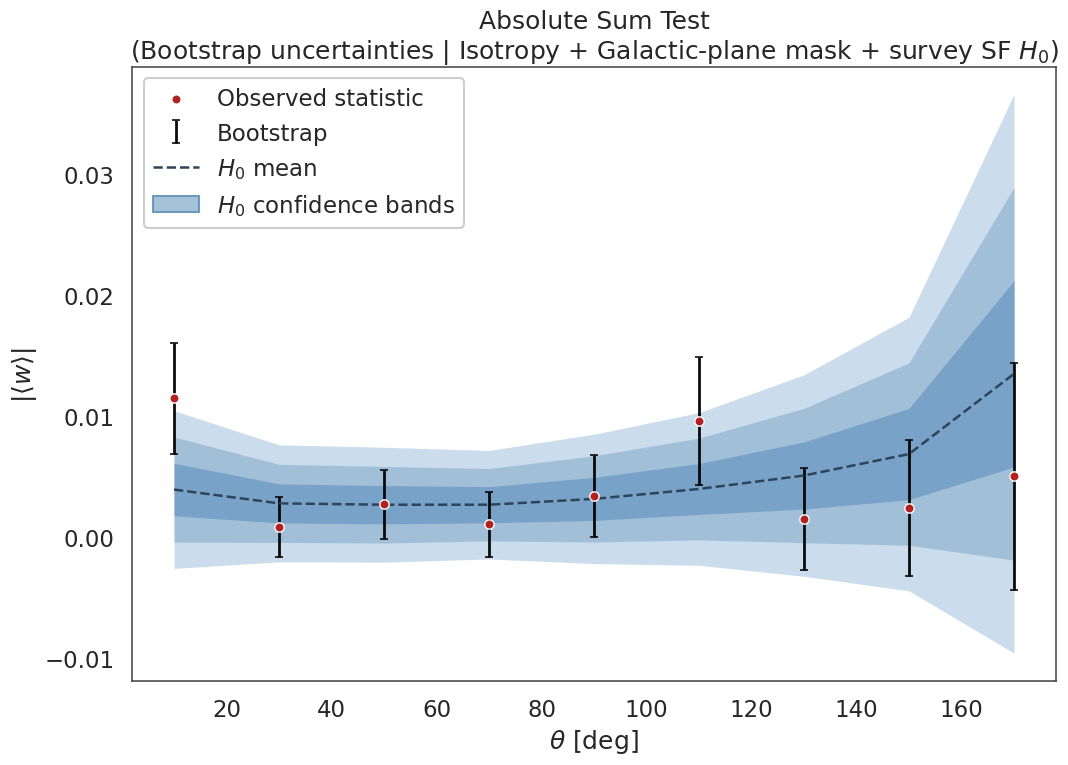

Saved: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/outputs/SFweightedIsotropy_mask_sf_gal20_bin10_nside32_smooth3/figures/absolute_anisotropy_bootstrap.png


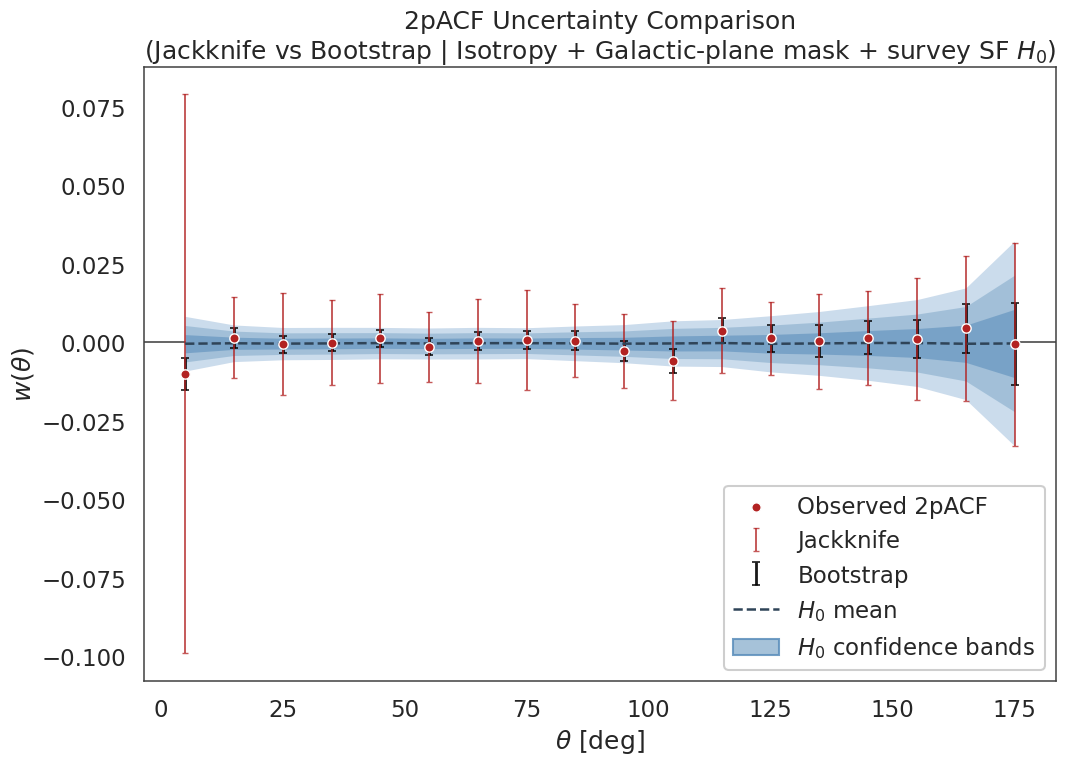

Saved: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/outputs/SFweightedIsotropy_mask_sf_gal20_bin10_nside32_smooth3/figures/2pacf_jk_vs_bootstrap.png


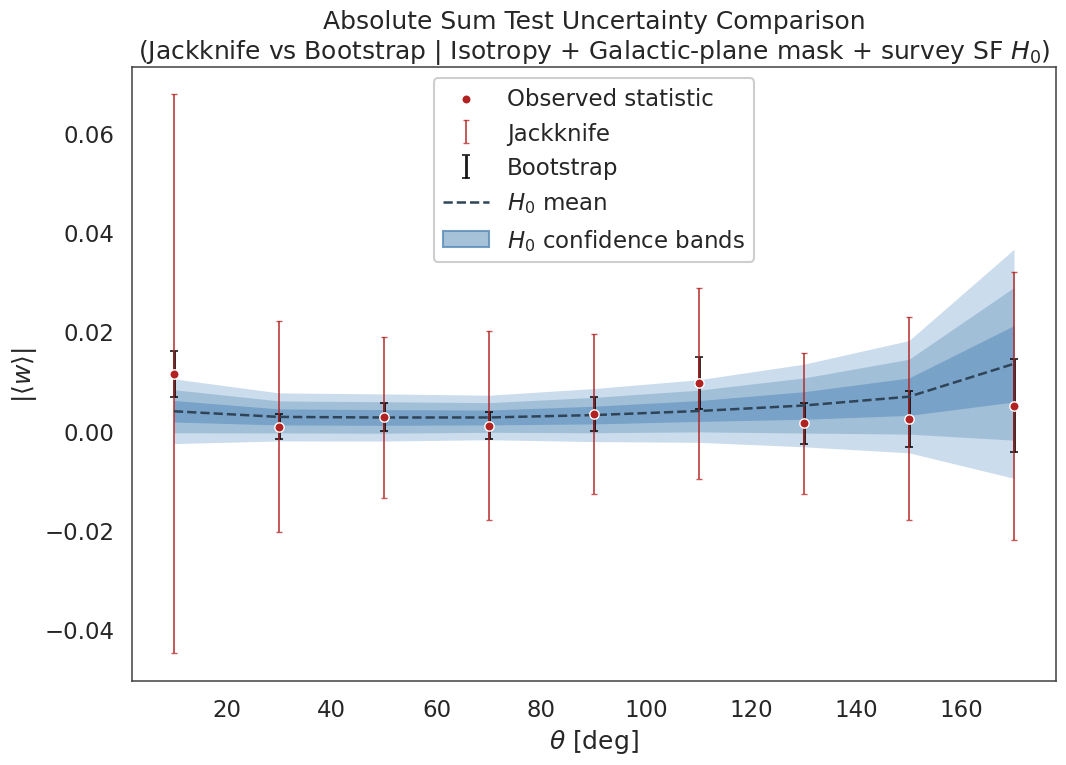

Saved: /home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/outputs/SFweightedIsotropy_mask_sf_gal20_bin10_nside32_smooth3/figures/absolute_anisotropy_jk_vs_bootstrap.png

PIPELINE FINISHED SUCCESSFULLY
{'context': RuntimeContext(config=AnalysisConfig(name='SFweightedIsotropy', project_root=PosixPath('/home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy'), outputs_root=PosixPath('/home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/outputs'), catalog_path=PosixPath('/home/brunowesley/projetos/FRB-isotropy-tests/Codes/frb-isotropy/data/SkyPosition.csv'), use_gal_mask=True, use_sel_func=True, n_jobs=100, gal_cut=20.0, min_sep=0.0, max_sep=180.0, bin_size=10, coarse_bins=(0.0, 20.0, 40.0, 60.0, 80.0, 100.0, 120.0, 140.0, 160.0, 180.0), nside_sf=32, smooth_sigma=3.0, perturbation_scale=1.0, n_rand_factor=20, n_ensemble=20, n_mocks_per_ensemble=50, random_seed=12345, mock_seed_base=100000, random_catalog_seed_base=200000, sf_perturbation_seed_base=300000,

In [4]:
result = main(config, save_outputs=False)
print(result)